In [1]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.utils import shuffle
import matplotlib.pyplot as plt


In [8]:
train_dir = '/content/drive/MyDrive/MRI/Training/'
test_dir = '/content/drive/MyDrive/MRI/Testing/'

# Load and shuffle the training dataset
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label)
    if os.path.isdir(label_path):
        for image in os.listdir(label_path):
            train_paths.append(os.path.join(label_path, image))
            train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    label_path = os.path.join(test_dir, label)
    if os.path.isdir(label_path):
        for image in os.listdir(label_path):
            test_paths.append(os.path.join(label_path, image))
            test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


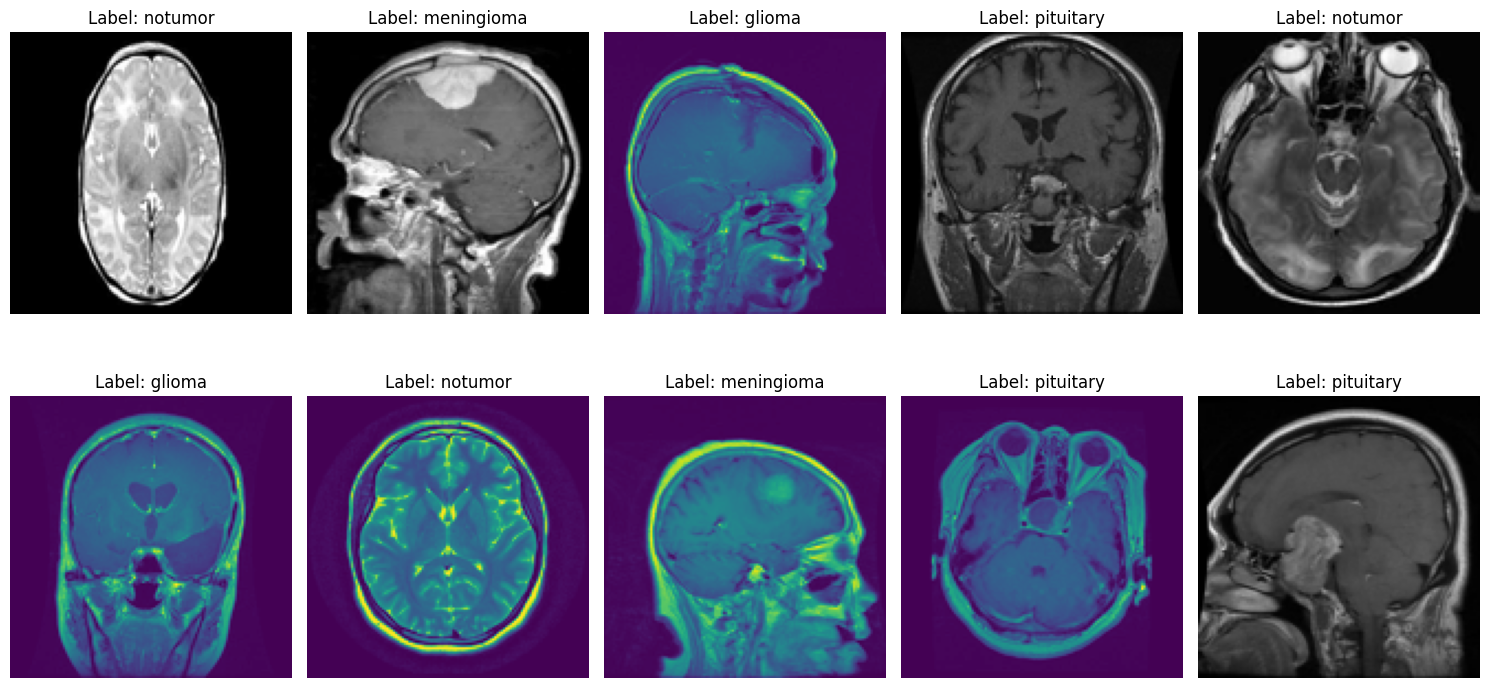

In [9]:
# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), min(10, len(train_paths)))

# Figure creation to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()
for i, index in enumerate(random_indices):
    img = Image.open(train_paths[index])
    img = img.resize((128, 128))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {train_labels[index]}")

plt.tight_layout()
plt.show()


In [10]:
IMAGE_SIZE = 128
batch_size = 12
epochs = 10
steps = int(np.ceil(len(train_paths) / batch_size))

# Label Encoding
def encode_label(labels):
    unique_classes = sorted(list(set(labels)))
    class_to_index = {cls: i for i, cls in enumerate(unique_classes)}
    encoded = [class_to_index[label] for label in labels]
    return np.array(encoded, dtype=np.int32), class_to_index

encoded_train_labels, class_map = encode_label(train_labels)
encoded_test_labels = np.array([class_map[label] for label in test_labels], dtype=np.int32)

# Image Augmentation
def augment_image(image):
    enhancer = ImageEnhance.Brightness(image)
    image = enhancer.enhance(random.uniform(0.8, 1.2))

    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(random.uniform(0.8, 1.2))

    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() > 0.5:
        image = image.transpose(Image.FLIP_TOP_BOTTOM)

    return image

# Image Loader with VGG16 Preprocessing
def open_images(paths, augment=False):
    images = []
    for path in paths:
        img = Image.open(path).convert("RGB")
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        if augment:
            img = augment_image(img)
        img_array = np.array(img, dtype=np.float32)
        img_array = preprocess_input(img_array)
        images.append(img_array)
    return np.array(images, dtype=np.float32)

# Infinite Data Generator for Keras fit
def datagen(paths, labels, batch_size=12, augment=True):
    steps = int(np.ceil(len(paths) / batch_size))
    while True:
        paths, labels = shuffle(paths, labels)
        for i in range(steps):
            batch_paths = paths[i*batch_size:(i+1)*batch_size]
            batch_labels = labels[i*batch_size:(i+1)*batch_size]
            batch_images = open_images(batch_paths, augment=augment)
            yield batch_images, np.array(batch_labels)

# Build Model using Pretrained VGG16
base_model = VGG16(include_top=False, weights="imagenet",
                   input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(len(class_map), activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Model
history = model.fit(
    datagen(train_paths, encoded_train_labels, batch_size=batch_size, augment=True),
    steps_per_epoch=steps,
    epochs=epochs
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
479/479 ━━━━━━━━━━━━━━━━━━━━ 1448s 3s/step - accuracy: 0.7040 - loss: 2.5396
Epoch 2/10
479/479 ━━━━━━━━━━━━━━━━━━━━ 50s 105ms/step - accuracy: 0.8078 - loss: 0.6464
Epoch 3/10
479/479 ━━━━━━━━━━━━━━━━━━━━ 49s 102ms/step - accuracy: 0.8418 - loss: 0.4710
Epoch 4/10
479/479 ━━━━━━━━━━━━━━━━━━━━ 52s 109ms/step - accuracy: 0.8620 - loss: 0.4057
Epoch 5/10
479/479 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - accuracy: 0.8794 - loss: 0.3404
Epoch 6/10
479/479 ━━━━━━━━━━━━━━━━━━━━ 48s 100ms/step - accuracy: 0.8930 - loss: 0.3059
Epoch 7/10
479/479 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - accuracy: 0.8928 - loss: 0.2998
Epoch 8/10
479/479 ━━━━━━━━━━━━━━━━━━━━ 48s 99ms/step - accuracy: 0.9017 - loss: 0.2785
Epoch 9/10
479/479 ━━━━━━━━━━━━━━━━━━━━ 47s 98ms/step - accuracy: 0.9132 - loss: 0.2396
Epoch 10/10
479/479 ━━━━━━━━━━━━━━━━━━━━ 48s 100ms/step - accuracy: 0.9157 - loss: 0.2356


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
model_path = "/content/drive/MyDrive/MRI/mri_classifier_vgg16.h5"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
model.save(model_path)
print(f"Model saved successfully to: {model_path}")


Model saved successfully to: /content/drive/MyDrive/MRI/mri_classifier_vgg16.h5



🔍 Evaluating the model on test data...
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 202ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.90      0.83      0.86       300
  meningioma       0.84      0.85      0.84       306
     notumor       0.97      0.98      0.97       405
   pituitary       0.94      0.98      0.96       300

    accuracy                           0.92      1311
   macro avg       0.91      0.91      0.91      1311
weighted avg       0.91      0.92      0.91      1311



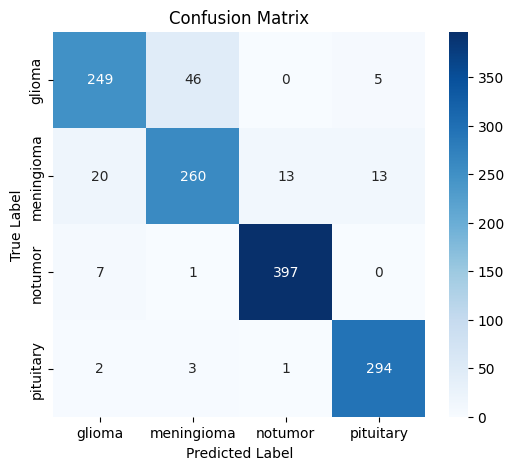

In [17]:
# Evaluate the model on test data
print("\n Evaluating the model on test data...")

# Load all test images
x_test = open_images(test_paths, augment=False)
y_test = encoded_test_labels

# Predict using trained model in batches of 32
y_pred_probs = model.predict(x_test, batch_size=32)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=list(class_map.keys())))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_map.keys(),
            yticklabels=class_map.keys(), cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


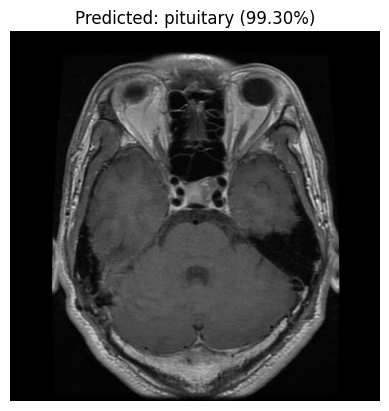

In [21]:
def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    img_array = np.array(img_resized, dtype=np.float32)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    current_model = model if 'model' in locals() and model is not None else load_model(model_path)
    pred = current_model.predict(img_array)
    pred_class = np.argmax(pred)
    confidence = np.max(pred)

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {list(class_map.keys())[pred_class]} ({confidence*100:.2f}%)")
    plt.show()

# Example test (replace path with an MRI image)
try:
    predict_image('/content/drive/MyDrive/MRI/Testing/pituitary/Te-piTr_0000.jpg')
except Exception as e:
    print(f"Could not load model or predict image: {e}")
